# Language-Model Posttraining

This notebook connects four objectives on small, inspectable examples: supervised fine-tuning, Bradley--Terry preference modeling, KL-regularized policy improvement, and DPO. Every calculation is implemented directly before any training-library abstraction is introduced.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 26524
rng = np.random.default_rng(SEED)
pairs = pd.read_csv('hh-rlhf-selected.csv')
pairs

,row_id,prompt,chosen,rejected
0,50000,some people say Nolan Ryan threw the fastest p...,Nolan Ryan's fastest pitch is more like 105 mi...,I'm afraid I don't know if that's right. But i...
1,50003,What are some good places to visit in Florence?,Perhaps you would like to go to Santa Croce fo...,Here are some places people recommend: The Uff...
2,50004,when did the first apple watch come out?,It was released in 2014.,It seems like there were a bunch of different ...
3,100007,Good idea. Thanks!,"My pleasure, any time!","You're welcome, have a nice day!"


The table is a small, fixed extract of the MIT-licensed Anthropic HH-RLHF training split. `chosen` means preferred under that collection protocol; it does not mean factually verified or universally best.

In [2]:
lengths = pd.DataFrame({
    "row_id": pairs.row_id,
    "chosen_words": pairs.chosen.str.split().str.len(),
    "rejected_words": pairs.rejected.str.split().str.len(),
})
lengths["chosen_minus_rejected"] = lengths.chosen_words - lengths.rejected_words
lengths

,row_id,chosen_words,rejected_words,chosen_minus_rejected
0,50000,16,28,-12
1,50003,37,24,13
2,50004,5,32,-27
3,100007,4,6,-2


## 1. Supervised fine-tuning loss

For teacher-forced token probabilities $p_1,\ldots,p_T$, sequence negative log likelihood is $-\sum_t\log p_t$.

In [3]:
def sequence_nll(correct_token_probabilities):
    probabilities = np.asarray(correct_token_probabilities, dtype=float)
    return -np.log(probabilities).sum()

probabilities = np.array([0.50, 0.25, 0.80])
print("sequence probability:", probabilities.prod())
print("sequence NLL:", sequence_nll(probabilities))
print("mean token NLL:", sequence_nll(probabilities) / len(probabilities))

sequence probability: 0.1
sequence NLL: 2.3025850929940455
mean token NLL: 0.7675283643313485


## 2. Bradley--Terry preference loss

The loss depends on the score difference $\Delta r=r(x,y^+)-r(x,y^-)$. Its derivative with respect to that difference is $\sigma(\Delta r)-1$.

In [4]:
def sigmoid(value):
    return 1 / (1 + np.exp(-value))

def preference_loss(score_chosen, score_rejected):
    difference = score_chosen - score_rejected
    probability = sigmoid(difference)
    loss = -np.log(probability)
    gradient_difference = probability - 1
    return probability, loss, gradient_difference

preference_loss(1.4, 0.2)

(np.float64(0.7685247834990175),
 np.float64(0.26328246733803135),
 np.float64(-0.23147521650098246))

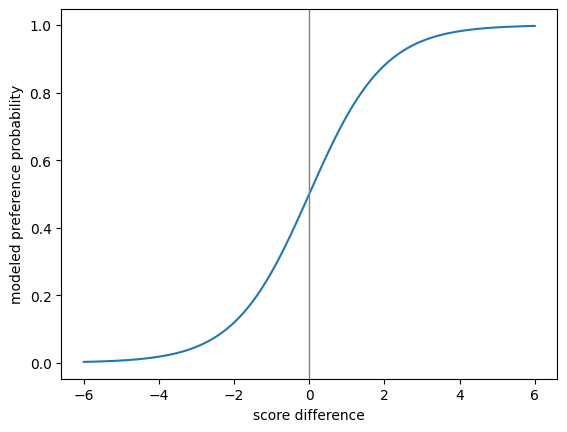

In [5]:
differences = np.linspace(-6, 6, 300)
plt.plot(differences, sigmoid(differences))
plt.axvline(0, color="gray", linewidth=1)
plt.xlabel("score difference")
plt.ylabel("modeled preference probability");

### Fit a tiny reward model from scratch

For illustration, represent each response by two visible features: word count and whether it contains a question mark. This is deliberately not a good semantic reward model; its failures make the role of representation and coverage explicit.

In [6]:
def response_features(text):
    words = len(text.split())
    return np.array([words / 50.0, float("?" in text), 1.0])

chosen_features = np.vstack([response_features(text) for text in pairs.chosen])
rejected_features = np.vstack([response_features(text) for text in pairs.rejected])
feature_difference = chosen_features - rejected_features

weights = np.zeros(feature_difference.shape[1])
learning_rate = 0.2
loss_history = []
for step in range(400):
    margins = feature_difference @ weights
    probabilities = sigmoid(margins)
    loss = -np.log(probabilities + 1e-12).mean()
    gradient = feature_difference.T @ (probabilities - 1) / len(pairs)
    weights -= learning_rate * gradient
    loss_history.append(loss)

print("weights [length, question mark, intercept]:", weights)
print("final loss:", loss_history[-1])
print("training probabilities:", sigmoid(feature_difference @ weights))

weights [length, question mark, intercept]: [-1.74304236 -2.63527267  0.        ]
final loss: 0.4949339604649705
training probabilities: [0.95493782 0.38860234 0.71935064 0.51742337]


The intercept cancels in every pair difference, so its gradient is zero. This is the reward-identifiability result in numerical form.

## 3. KL-regularized optimal policy

For a fixed reward vector, the exact optimizer is $\pi^*(y)\propto\pi_{m ref}(y)\exp(r(y)/eta)$.

In [7]:
def kl_optimal_policy(reference, reward, beta):
    reference = np.asarray(reference, dtype=float)
    reward = np.asarray(reward, dtype=float)
    unnormalized = reference * np.exp(reward / beta)
    return unnormalized / unnormalized.sum()

reference = np.array([0.5, 0.5])
reward = np.array([1.0, 0.0])
for beta in [0.25, 0.5, 1.0, 2.0]:
    policy = kl_optimal_policy(reference, reward, beta)
    kl = np.sum(policy * np.log(policy / reference))
    objective = policy @ reward - beta * kl
    print(f"beta={beta:>4}: policy={policy.round(3)}, KL={kl:.3f}, objective={objective:.3f}")

beta=0.25: policy=[0.982 0.018], KL=0.603, objective=0.831
beta= 0.5: policy=[0.881 0.119], KL=0.328, objective=0.717
beta= 1.0: policy=[0.731 0.269], KL=0.111, objective=0.620
beta= 2.0: policy=[0.622 0.378], KL=0.030, objective=0.562


## 4. Direct preference optimization

DPO applies a logistic preference loss to the difference of policy/reference log-ratios.

In [8]:
def dpo_loss(policy_chosen, policy_rejected,
             reference_chosen, reference_rejected, beta=1.0):
    margin = beta * (
        np.log(policy_chosen / reference_chosen)
        - np.log(policy_rejected / reference_rejected)
    )
    return margin, -np.log(sigmoid(margin))

dpo_loss(0.30, 0.10, 0.20, 0.20, beta=1.0)

(np.float64(1.0986122886681096), np.float64(0.28768207245178107))

In [9]:
# Optimize one two-response policy parameter directly.
logit = 0.0
reference_chosen = reference_rejected = 0.5
history = []
for step in range(80):
    chosen_probability = sigmoid(logit)
    rejected_probability = 1 - chosen_probability
    margin, loss = dpo_loss(chosen_probability, rejected_probability,
                            reference_chosen, reference_rejected, beta=0.5)
    # For a two-response softmax, d margin / d logit = beta.
    gradient = (sigmoid(margin) - 1) * 0.5
    logit -= 0.5 * gradient
    history.append((loss, chosen_probability))

print("final chosen probability:", sigmoid(logit))
print("final DPO loss:", history[-1][0])

final chosen probability: 0.9875688972452028
final DPO loss: 0.10762906435600327


## 5. Reinforcement learning with verifiable rewards

Sections 2 to 4 all trace back to a *learned* reward: a human said which of two
responses was better, and a model was fitted to those judgements. On tasks where
a program can check the answer, that detour is unnecessary. The reward is the
checker's verdict, and a checker cannot be flattered by a longer answer or a
more confident tone.

The task here is two-digit addition. The policy sees $(a,b)$ and puts a
distribution over the answers $0,\dots,18$; it is never shown $a+b$. Its only
feedback is a program returning $1$ or $0$.

In [10]:
DIGITS = 10
ANSWERS = 2 * DIGITS - 1           # 0 through 18
grpo_rng = np.random.default_rng(SEED + 5)

def prompt_features(a, b):
    # One-hot the two digits. The answer must be inferred from reward alone.
    features = np.zeros((len(a), 2 * DIGITS))
    features[np.arange(len(a)), a] = 1.0
    features[np.arange(len(a)), DIGITS + b] = 1.0
    return features

def policy_probabilities(weights, features):
    scores = features @ weights.T
    scores = scores - scores.max(axis=1, keepdims=True)
    exponentiated = np.exp(scores)
    return exponentiated / exponentiated.sum(axis=1, keepdims=True)

def verifier(answer, a, b):
    # A program, not a model. It cannot be persuaded.
    return (answer == a + b).astype(float)

# The policy class is expressive enough to be exactly right: setting
# w[y, a] = 2ya - y^2/2 makes the score 2y(a+b) - y^2, which is maximal at y=a+b.
exact = np.zeros((ANSWERS, 2 * DIGITS))
for y in range(ANSWERS):
    exact[y, :DIGITS] = [2 * y * a - y * y / 2 for a in range(DIGITS)]
    exact[y, DIGITS:] = [2 * y * b - y * y / 2 for b in range(DIGITS)]
check_a, check_b = grpo_rng.integers(0, DIGITS, 5000), grpo_rng.integers(0, DIGITS, 5000)
exact_accuracy = (policy_probabilities(exact, prompt_features(check_a, check_b)).argmax(1)
                  == check_a + check_b).mean()
print(f"accuracy of the hand-constructed weights: {exact_accuracy:.3f}")
print("So anything the run below fails to learn is a signal problem, not a capacity problem.")

accuracy of the hand-constructed weights: 1.000
So anything the run below fails to learn is a signal problem, not a capacity problem.


### The group-relative advantage

GRPO removes the value network. For one prompt it samples a **group** of $G$
responses, scores them, and standardizes the scores *within that group*:

$$\widehat A_i=\frac{r_i-\bar r}{\operatorname{sd}(r)},\qquad
\bar r=\frac1G\sum_j r_j .$$

The group's own mean is the baseline. Read the formula once more and the failure
mode is visible before any code runs: if all $G$ responses earn the same reward
— all correct, or all wrong — then $r_i-\bar r=0$ for every one of them, and the
prompt contributes nothing to the update. Watch that column below.

In [11]:
def grpo(steps=2000, group=8, batch=64, learning_rate=3.0, beta=0.002, seed=SEED + 6):
    rng = np.random.default_rng(seed)
    weights = np.zeros((ANSWERS, 2 * DIGITS))
    reference = weights.copy()
    trace = []
    for step in range(steps):
        a, b = rng.integers(0, DIGITS, batch), rng.integers(0, DIGITS, batch)
        features = prompt_features(a, b)
        probabilities = policy_probabilities(weights, features)

        # Sample a group of G answers per prompt and let the verifier score them.
        sampled = np.array([rng.choice(ANSWERS, size=group, p=probabilities[i])
                            for i in range(batch)])
        rewards = verifier(sampled, a[:, None], b[:, None])

        # Standardize within the group: this is the whole of GRPO's advantage.
        advantage = ((rewards - rewards.mean(1, keepdims=True))
                     / (rewards.std(1, keepdims=True) + 1e-4))

        # d/dw of A * log pi is A * (onehot(y) - p) outer features.
        gradient = np.zeros_like(weights)
        for g in range(group):
            indicator = np.zeros((batch, ANSWERS))
            indicator[np.arange(batch), sampled[:, g]] = 1.0
            gradient += (advantage[:, g:g + 1] * (indicator - probabilities)).T @ features
        gradient /= batch * group

        # Stay near the reference policy, as the KL term in the objective asks.
        gradient -= beta * ((probabilities - policy_probabilities(reference, features)).T
                            @ features) / batch
        weights += learning_rate * gradient

        if step % 250 == 0 or step == steps - 1:
            test_a, test_b = rng.integers(0, DIGITS, 3000), rng.integers(0, DIGITS, 3000)
            greedy = policy_probabilities(weights, prompt_features(test_a, test_b)).argmax(1)
            trace.append({
                "step": step,
                "mean_reward": rewards.mean(),
                "greedy_accuracy": (greedy == test_a + test_b).mean(),
                "dead_groups": (rewards.std(1) < 1e-9).mean(),
            })
    return weights, pd.DataFrame(trace)

grpo_weights, grpo_trace = grpo()
grpo_trace.round(3)

,step,mean_reward,greedy_accuracy,dead_groups
0,0,0.049,0.205,0.641
1,250,0.102,0.296,0.406
2,500,0.166,0.356,0.625
3,750,0.346,0.390,0.656
4,1000,0.420,0.436,0.672
5,1250,0.496,0.453,0.719
6,1500,0.486,0.460,0.828
7,1750,0.508,0.460,0.859
8,1999,0.441,0.461,0.922


accuracy 0.205 -> 0.461 (guessing is 0.053, the exact policy is 1.000)
groups with zero advantage: 0.64 -> 0.92


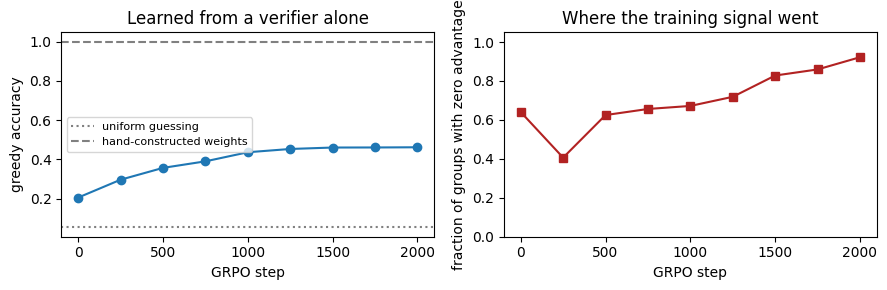

In [12]:
fig, (left, right) = plt.subplots(1, 2, figsize=(9, 3))
left.plot(grpo_trace.step, grpo_trace.greedy_accuracy, "o-")
left.axhline(1 / ANSWERS, color="gray", linestyle=":", label="uniform guessing")
left.axhline(1.0, color="gray", linestyle="--", label="hand-constructed weights")
left.set_xlabel("GRPO step"); left.set_ylabel("greedy accuracy"); left.legend(fontsize=8)
left.set_title("Learned from a verifier alone")

right.plot(grpo_trace.step, grpo_trace.dead_groups, "s-", color="firebrick")
right.set_ylim(0, 1.05); right.set_xlabel("GRPO step")
right.set_ylabel("fraction of groups with zero advantage")
right.set_title("Where the training signal went")
fig.tight_layout()

first, last = grpo_trace.iloc[0], grpo_trace.iloc[-1]
print(f"accuracy {first.greedy_accuracy:.3f} -> {last.greedy_accuracy:.3f} "
      f"(guessing is {1/ANSWERS:.3f}, the exact policy is 1.000)")
print(f"groups with zero advantage: {first.dead_groups:.2f} -> {last.dead_groups:.2f}")

Both halves of that figure matter. A program that only ever says *right* or
*wrong* taught a policy to add, starting from uniform — no labelled answers, no
preference pairs, no reward model. And then it stopped, well short of the
accuracy the same weights can express.

The right-hand panel says why. As the policy sharpens, its $G$ samples for a
given prompt increasingly agree, so more and more groups come back all-correct
or all-wrong. Those groups have zero advantage: they cost a full forward pass
each and contribute exactly nothing to the gradient. Late in this run almost
every group is dead, and the run is paying for samples it cannot learn from.

This is why practical RLVR keeps the policy from collapsing — sampling above
temperature one, an entropy bonus, or curriculum that keeps prompts near the
edge of what the policy can currently do — and why implementations discard
zero-variance groups rather than backpropagating through them.

## Try It

1. Change the correct-token probabilities in the SFT example. Which single token dominates the sequence loss?
2. Add the same constant to both Bradley--Terry scores. Confirm that probability and loss do not change.
3. Vary $eta$ in the KL optimizer. Plot learned reward against KL divergence.
4. Reverse one HH-RLHF pair and refit the toy reward model. How sensitive are its probabilities to one label?
5. Change the DPO reference probabilities while holding the current policy fixed. Why does the loss change?5. In `grpo`, raise the sampling temperature (divide the scores by $\tau>1$
   before the softmax) and watch the dead-group fraction. Does accuracy improve,
   and what does it cost?
6. Discard zero-variance groups before forming the gradient. The update is
   unchanged; how much sampling compute is saved by the last step?
7. Set the group size to 2 and then to 32. Which term in the advantage does
   group size control, and what happens to the variance of the update?
